In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

In [22]:
df = pd.read_csv("Iris_Dataset.csv")
df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,7.0,3.2,4.7,1.4,Iris-versicolor


LOGISTIC REGRESSION RESULTS
----------------------------------------
Accuracy: 0.5000
Precision (macro): 0.5000
Recall (macro): 0.5000
F1 Score (macro): 0.5000
MSE: 0.0000
MAE: 0.0000
R² Score: 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         1
Iris-versicolor       0.00      0.00      0.00         1
 Iris-virginica       0.50      0.50      0.50         2

       accuracy                           0.50         4
      macro avg       0.50      0.50      0.50         4
   weighted avg       0.50      0.50      0.50         4



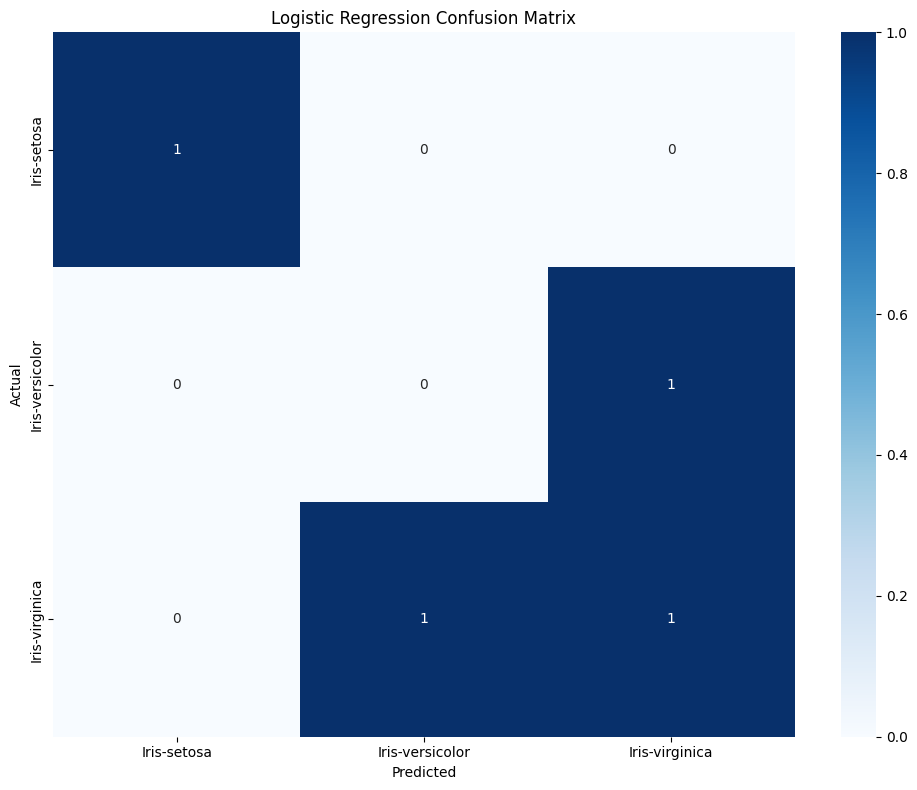

j:\Work\Career\AI And Data Science\Internships\IT Club Internship - 2025\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


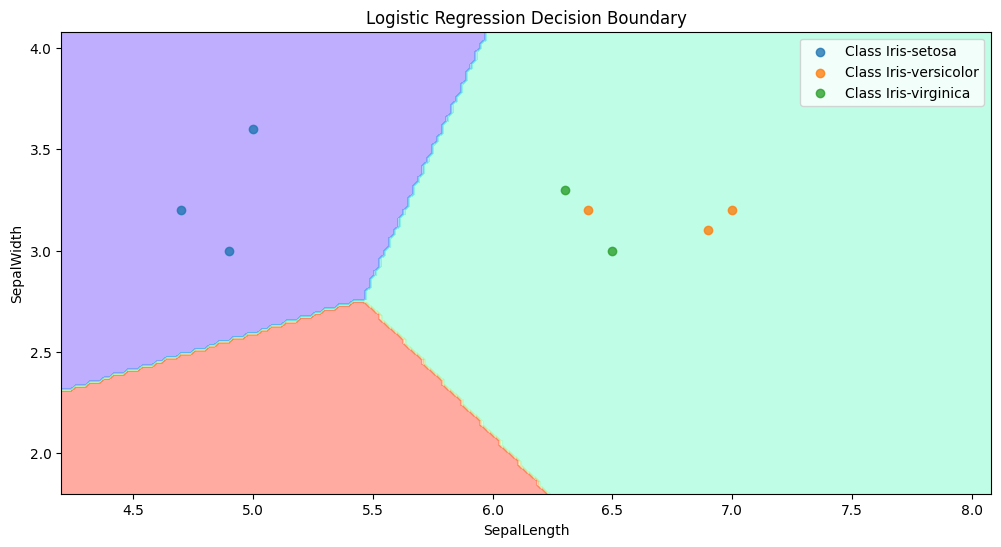

In [23]:
X = df.drop(["Species", "Id"], axis=1, errors="ignore")
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)

print("LOGISTIC REGRESSION RESULTS")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

binary_true = np.array([1 if val == lr_model.classes_[0] else 0 for val in y_test])
binary_pred = np.array([1 if val == lr_model.classes_[0] else 0 for val in y_pred])

print(f"MSE: {mean_squared_error(binary_true, binary_pred):.4f}")
print(f"MAE: {mean_absolute_error(binary_true, binary_pred):.4f}")
print(f"R² Score: {r2_score(binary_true, binary_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

if X.shape[1] >= 2:
    plt.figure(figsize=(12, 6))

    feature_idx = [0, 1]

    X_values = X.values
    x_min, x_max = (
        X_values[:, feature_idx[0]].min() - 0.5,
        X_values[:, feature_idx[0]].max() + 0.5,
    )
    y_min, y_max = (
        X_values[:, feature_idx[1]].min() - 0.5,
        X_values[:, feature_idx[1]].max() + 0.5,
    )
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    if X.shape[1] > 2:
        X_train_values = X_train.values
        dummy_vals = np.tile(
            np.mean(X_train_values[:, 2:], axis=0), (grid_points.shape[0], 1)
        )
        grid_points = np.column_stack([grid_points, dummy_vals])

    grid_points_scaled = scaler.transform(grid_points)

    Z = lr_model.predict(grid_points_scaled)
    Z = np.array([np.where(lr_model.classes_ == z)[0][0] for z in Z])

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4, cmap="rainbow")

    for i, class_label in enumerate(np.unique(y_train)):
        class_mask = np.array(y_train == class_label)
        plt.scatter(
            X_train.values[class_mask, feature_idx[0]],
            X_train.values[class_mask, feature_idx[1]],
            alpha=0.8,
            label=f"Class {class_label}",
        )

    plt.xlabel(X.columns[feature_idx[0]])
    plt.ylabel(X.columns[feature_idx[1]])
    plt.title("Logistic Regression Decision Boundary")
    plt.legend()
    plt.show()

j:\Work\Career\AI And Data Science\Internships\IT Club Internship - 2025\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
j:\Work\Career\AI And Data Science\Internships\IT Club Internship - 2025\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
j:\Work\Career\AI And Data Science\Internships\IT Club Internship - 2025\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.

DECISION TREE RESULTS
----------------------------------------
Accuracy: 0.5000
Precision (macro): 0.4444
Recall (macro): 0.5000
F1 Score (macro): 0.3889
MSE: 0.5000
MAE: 0.5000
R² Score: -1.6667

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       0.33      1.00      0.50         1
Iris-versicolor       0.00      0.00      0.00         1
 Iris-virginica       1.00      0.50      0.67         2

       accuracy                           0.50         4
      macro avg       0.44      0.50      0.39         4
   weighted avg       0.58      0.50      0.46         4



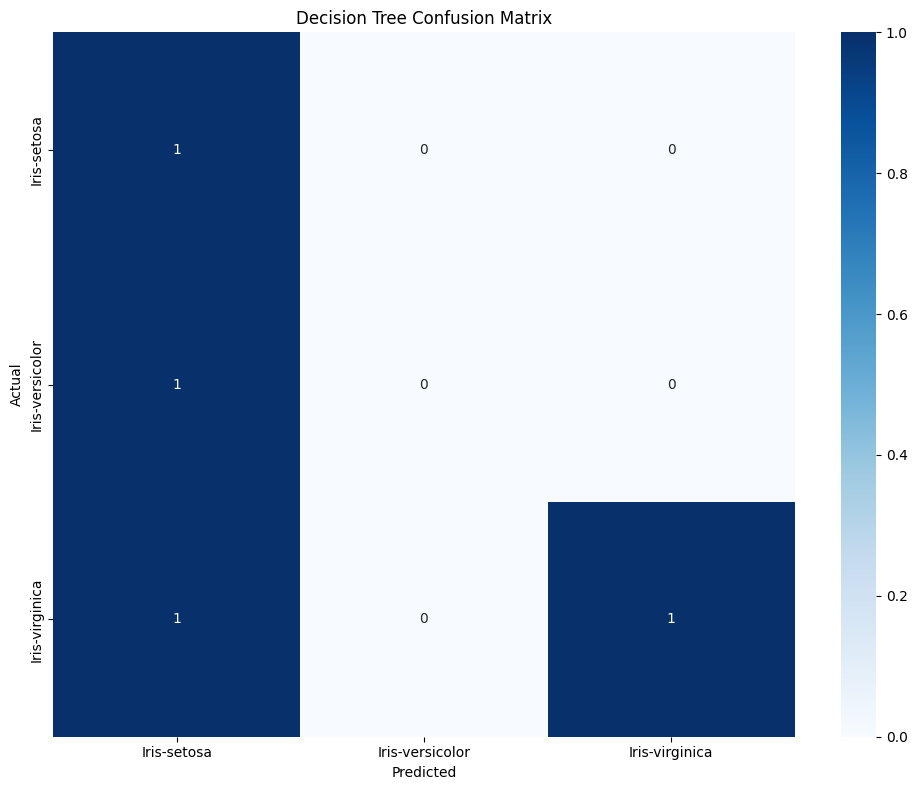

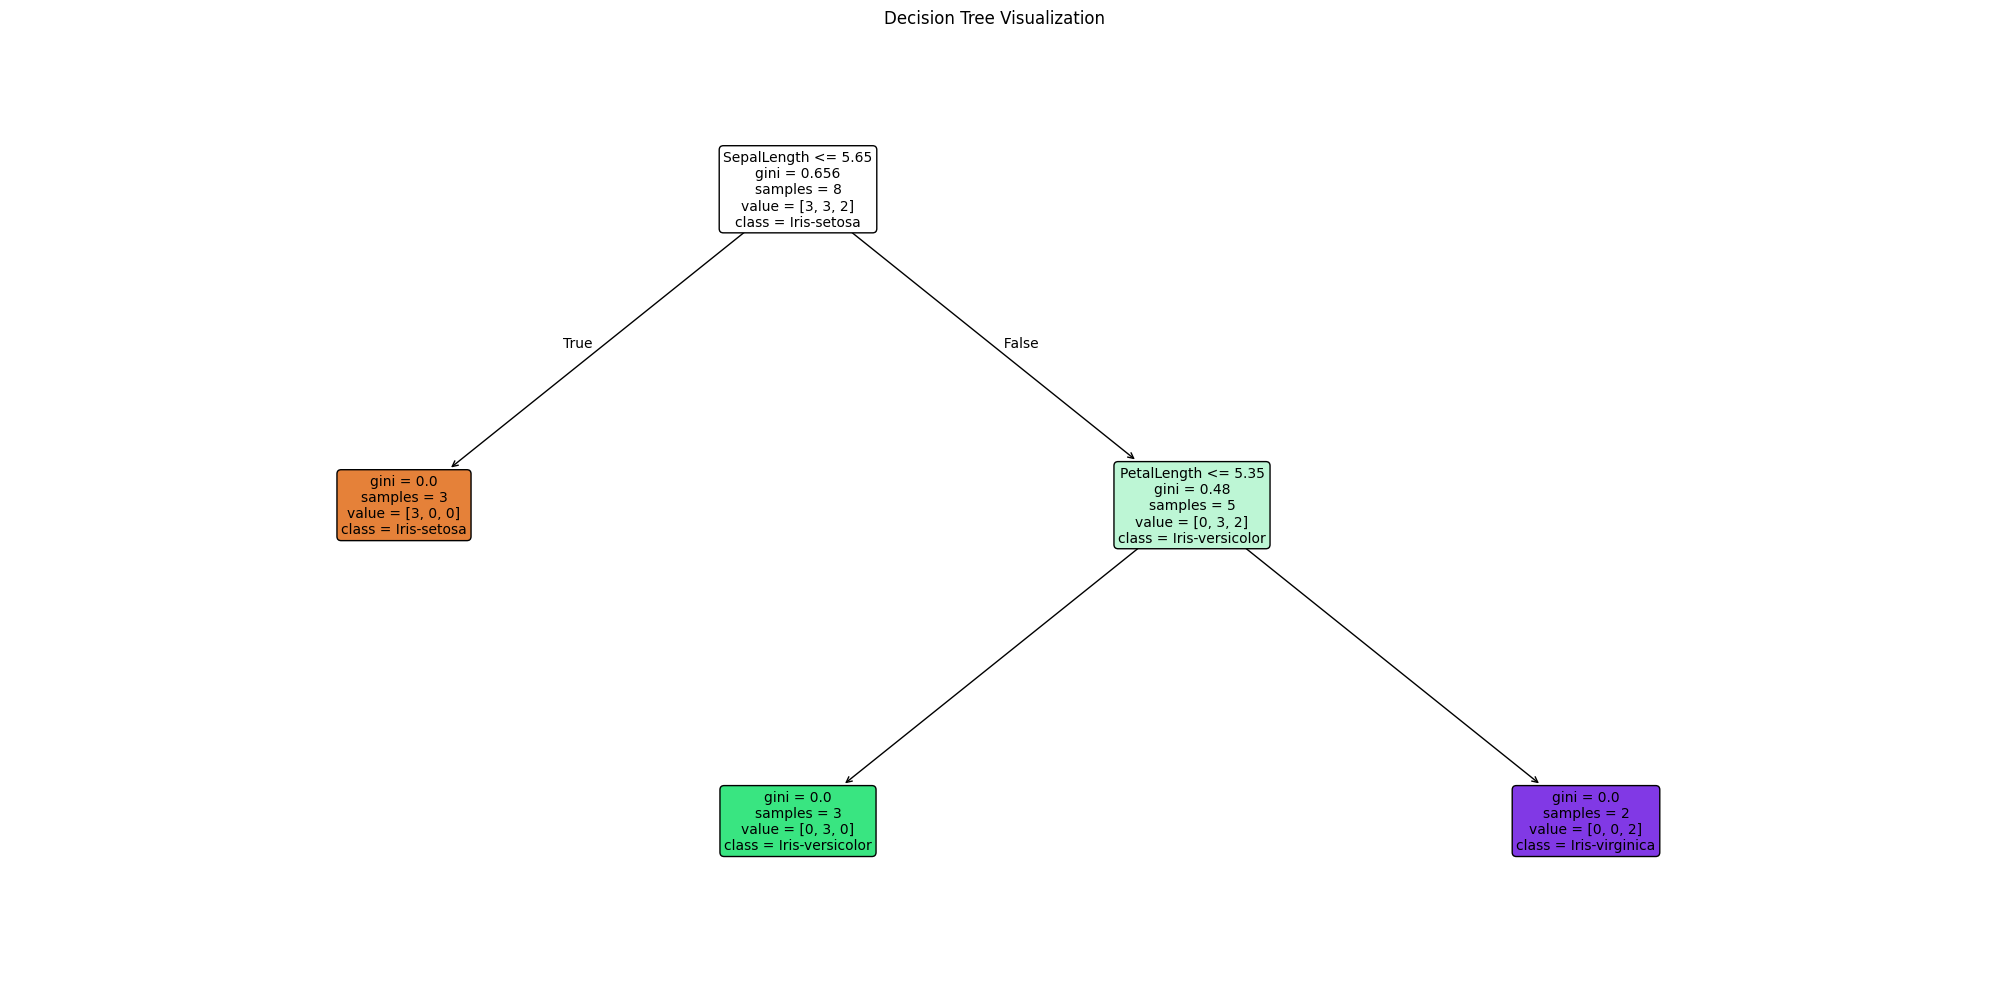

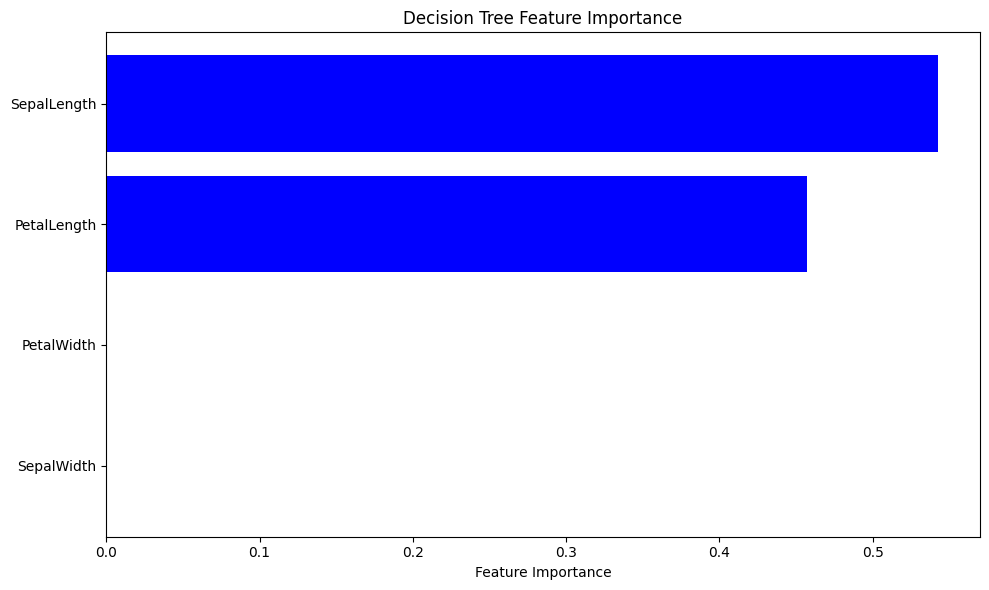

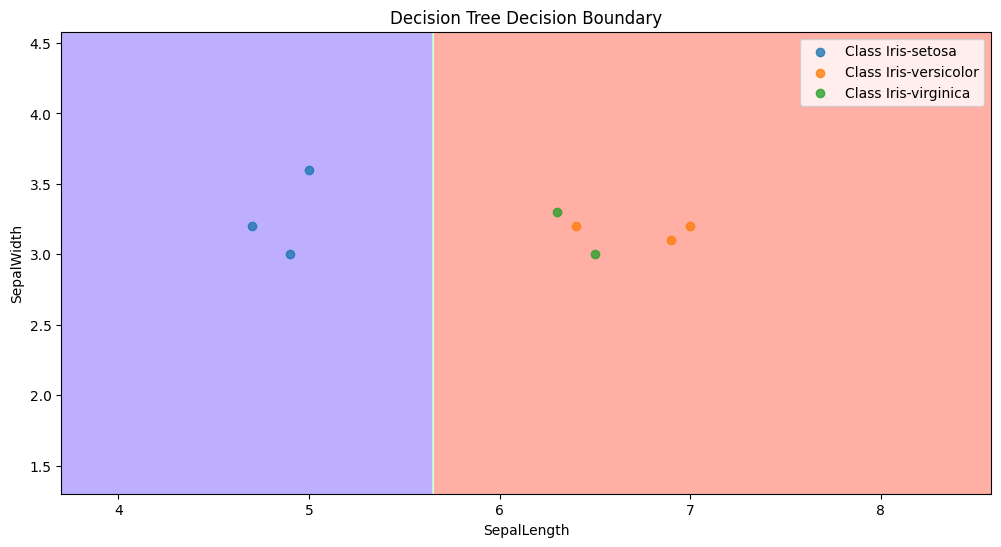

In [24]:
X = df.drop(["Species", "Id"], axis=1, errors="ignore")
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_model.fit(X_train.values, y_train)

y_pred = dt_model.predict(X_test.values)
y_pred_proba = dt_model.predict_proba(X_test.values)

print("DECISION TREE RESULTS")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

binary_true = np.array([1 if val == dt_model.classes_[0] else 0 for val in y_test])
binary_pred = np.array([1 if val == dt_model.classes_[0] else 0 for val in y_pred])

print(f"MSE: {mean_squared_error(binary_true, binary_pred):.4f}")
print(f"MAE: {mean_absolute_error(binary_true, binary_pred):.4f}")
print(f"R² Score: {r2_score(binary_true, binary_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dt_model.classes_,
    yticklabels=dt_model.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    filled=True,
    feature_names=list(X.columns),
    class_names=list(dt_model.classes_),
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
features = X.columns
importances = dt_model.feature_importances_
indices = np.argsort(importances)

plt.barh(range(len(indices)), importances[indices], color="b")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

if X.shape[1] >= 2:
    plt.figure(figsize=(12, 6))

    feature_idx = [0, 1]

    X_values = X.values
    x_min, x_max = (
        X_values[:, feature_idx[0]].min() - 1,
        X_values[:, feature_idx[0]].max() + 1,
    )
    y_min, y_max = (
        X_values[:, feature_idx[1]].min() - 1,
        X_values[:, feature_idx[1]].max() + 1,
    )
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    if X.shape[1] > 2:
        X_train_values = X_train.values
        dummy_vals = np.tile(
            np.mean(X_train_values[:, 2:], axis=0), (grid_points.shape[0], 1)
        )
        grid_points = np.column_stack([grid_points, dummy_vals])

    Z = dt_model.predict(grid_points)
    Z = np.array([np.where(dt_model.classes_ == z)[0][0] for z in Z])

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4, cmap="rainbow")

    for i, class_label in enumerate(np.unique(y_train)):
        class_mask = np.array(y_train == class_label)
        plt.scatter(
            X_train.values[class_mask, feature_idx[0]],
            X_train.values[class_mask, feature_idx[1]],
            alpha=0.8,
            label=f"Class {class_label}",
        )

    plt.xlabel(X.columns[feature_idx[0]])
    plt.ylabel(X.columns[feature_idx[1]])
    plt.title("Decision Tree Decision Boundary")
    plt.legend()
    plt.show()

Best value of k: 1
K-NEAREST NEIGHBORS RESULTS
----------------------------------------
Accuracy: 0.7500
Precision (macro): 0.5556
Recall (macro): 0.6667
F1 Score (macro): 0.6000
MSE: 0.0000
MAE: 0.0000
R² Score: 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         1
Iris-versicolor       0.00      0.00      0.00         1
 Iris-virginica       0.67      1.00      0.80         2

       accuracy                           0.75         4
      macro avg       0.56      0.67      0.60         4
   weighted avg       0.58      0.75      0.65         4



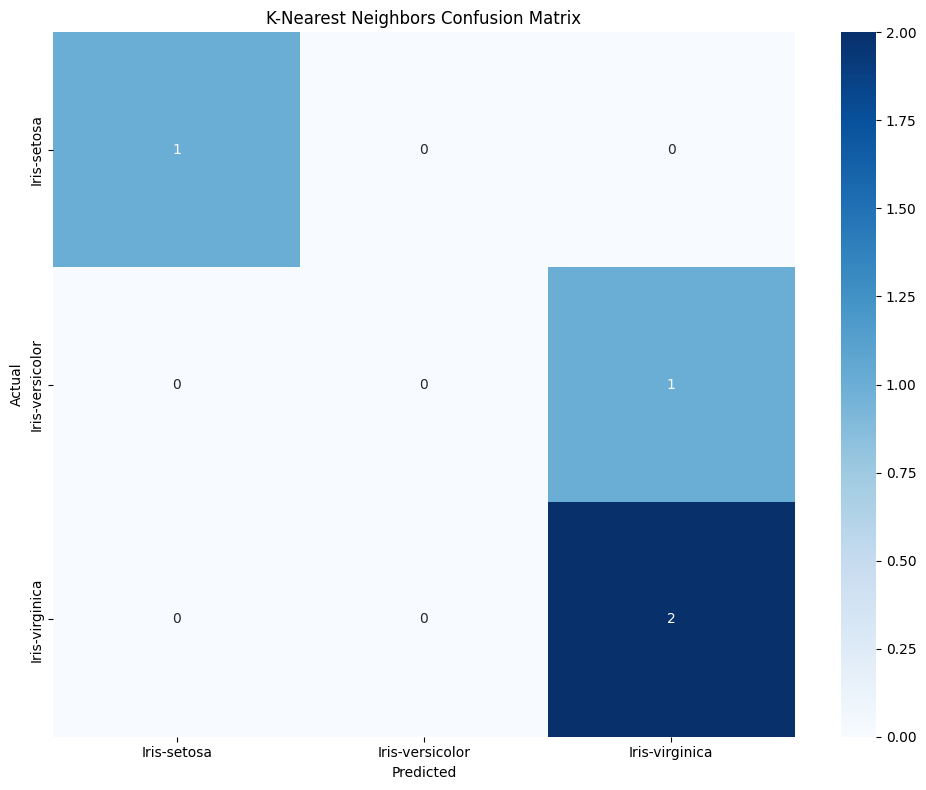

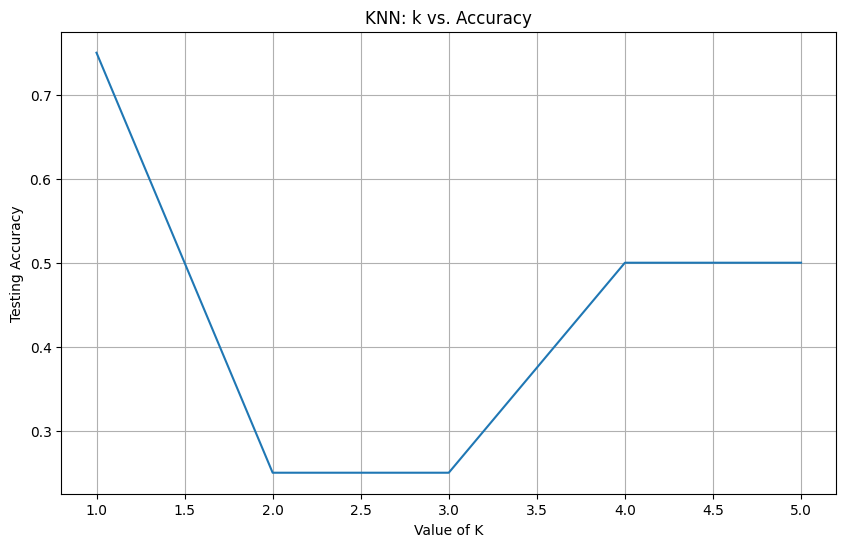

j:\Work\Career\AI And Data Science\Internships\IT Club Internship - 2025\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


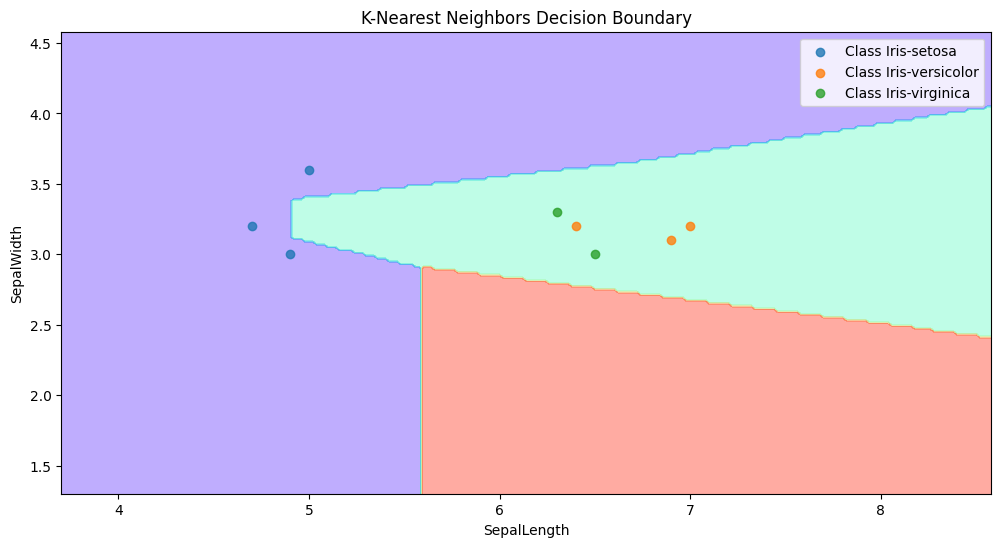

In [26]:
X = df.drop(["Species", "Id"], axis=1, errors="ignore")
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_range = range(1, 6)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test)
    k_scores.append(score)

best_k = k_range[np.argmax(k_scores)]
print(f"Best value of k: {best_k}")

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)
y_pred_proba = knn_model.predict_proba(X_test_scaled)

print("K-NEAREST NEIGHBORS RESULTS")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(
    f"Precision (macro): {precision_score(y_test, y_pred, average='macro', zero_division=0):.4f}"
)
print(
    f"Recall (macro): {recall_score(y_test, y_pred, average='macro', zero_division=0):.4f}"
)
print(
    f"F1 Score (macro): {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}"
)

binary_true = np.array([1 if val == knn_model.classes_[0] else 0 for val in y_test])
binary_pred = np.array([1 if val == knn_model.classes_[0] else 0 for val in y_pred])

print(f"MSE: {mean_squared_error(binary_true, binary_pred):.4f}")
print(f"MAE: {mean_absolute_error(binary_true, binary_pred):.4f}")
print(
    f"R² Score: {r2_score(binary_true, binary_pred) if np.var(binary_true) != 0 else 1.0:.4f}"
)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=knn_model.classes_,
    yticklabels=knn_model.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("K-Nearest Neighbors Confusion Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores)
plt.xlabel("Value of K")
plt.ylabel("Testing Accuracy")
plt.title("KNN: k vs. Accuracy")
plt.grid(True)
plt.show()

if X.shape[1] >= 2:
    plt.figure(figsize=(12, 6))

    feature_idx = [0, 1]

    X_values = X.values
    x_min, x_max = (
        X_values[:, feature_idx[0]].min() - 1,
        X_values[:, feature_idx[0]].max() + 1,
    )
    y_min, y_max = (
        X_values[:, feature_idx[1]].min() - 1,
        X_values[:, feature_idx[1]].max() + 1,
    )
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    if X.shape[1] > 2:
        X_train_values = X_train.values
        other_features = np.tile(
            np.mean(X_train_values[:, 2:], axis=0), (grid_points.shape[0], 1)
        )
        full_grid = np.column_stack([grid_points, other_features])
        full_grid_scaled = scaler.transform(full_grid)
    else:
        full_grid_scaled = scaler.transform(grid_points)

    Z = knn_model.predict(full_grid_scaled)
    Z = np.array([np.where(knn_model.classes_ == z)[0][0] for z in Z])

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4, cmap="rainbow")

    for i, class_label in enumerate(np.unique(y_train)):
        mask = y_train.values == class_label
        X_train_values = X_train.values
        plt.scatter(
            X_train_values[mask, feature_idx[0]],
            X_train_values[mask, feature_idx[1]],
            alpha=0.8,
            label=f"Class {class_label}",
        )

    plt.xlabel(X.columns[feature_idx[0]])
    plt.ylabel(X.columns[feature_idx[1]])
    plt.title("K-Nearest Neighbors Decision Boundary")
    plt.legend()
    plt.show()